## Comprobar HW y SW instalado








In [ ]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   2
  On-line CPU(s) list:    0,1
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   1
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.38
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 cl
                          flush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc re
                          p_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3
                           fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand
                           hypervisor lahf_lm abm 3dnowprefetch i

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


In [ ]:
!nvidia-smi

Sun Oct 20 10:39:56 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   41C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Tutorial: Multiplicación de matrices en GPU



Adaptación de los ejemplos disponibles en los siguientes enlaces:
*  https://medium.com/@harsh20111997/cuda-programming-2d-matrix-multiplication-1aa774b8d703
* https://www.quantstart.com/articles/Matrix-Matrix-Multiplication-on-the-GPU-with-Nvidia-CUDA/

In [ ]:
! mkdir cuda

mkdir: cannot create directory ‘cuda’: File exists


In [ ]:
%%writefile cuda/MatMult.cu

#include <stdio.h>
#include <cuda.h>
#include <cuda_runtime.h>
#include <sys/time.h>

#define N 3

__global__ void matrix_mul(int *a, int *b, int *c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;
    int sum = 0;
    if (i < n && j < n) {
        for (int k = 0; k < n; k++)
            sum += a[i * n + k] * b[k * n + j];
        c[i * n + j] = sum;
    }
}

void printMat( int *mm, char *nombre, int n){
   for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++)
					printf(" %c[%d][%d] = %d ",nombre[0] ,i, j, mm[i * n + j]);
        printf("\n");
    }
}

int main() {
    int n = N;
    int *a, *b, *c;
    int *d_a, *d_b, *d_c;
    int size = n * n * sizeof(int);
		char matA[]= "A";
		char matB[]= "B";
		char matC[]= "C";
    struct timeval start_time, end_time;

    a = (int *)malloc(size);
    b = (int *)malloc(size);
    c = (int *)malloc(size);

		// Inicializacion de valores
    for (int i = 0; i < n; i++)
        for (int j = 0; j < n; j++) {
            a[i * n + j] = i + j;
            b[i * n + j] = i * j;
        }

    cudaMalloc((void **)&d_a, size);
    cudaMalloc((void **)&d_b, size);
    cudaMalloc((void **)&d_c, size);

    gettimeofday(&start_time, NULL);
    cudaMemcpy(d_a, a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, size, cudaMemcpyHostToDevice);

    dim3 blockSize(N, N);
    dim3 gridSize((n + N - 1) / N, (n + N - 1) / N);
    matrix_mul<<<gridSize, blockSize>>>(d_a, d_b, d_c, n);

    cudaMemcpy(c, d_c, size, cudaMemcpyDeviceToHost);
    gettimeofday(&end_time, NULL);

    /*printMat( a, matA, n); printf("\n");
    printMat( b, matB, n); printf("\n");
		printMat( c, matC, n);*/

		/* for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++)
					printf(" c[ %d ][ %d ] = %d ", i, j, c[i * n + j]);
        printf("\n");
    }
		*/

    FILE *time = fopen("time_matmult_2D.txt", "a");;

    double elapsed_time = ((end_time.tv_sec - start_time.tv_sec) + (end_time.tv_usec - start_time.tv_usec) / 1e6);

    fprintf(time, "%d %lf\n", n, elapsed_time);

    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);
    free(a);
    free(b);
    free(c);
    fclose(time);
    return 0;
}

Overwriting cuda/MatMult.cu


In [ ]:
!nvcc cuda/MatMult.cu -o cuda/MatMult
!ls -la cuda

cuda/MatMult.cu(33): warning #177-D: variable "matA" was declared but never referenced
    char matA[]= "A";
         ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

cuda/MatMult.cu(34): warning #177-D: variable "matB" was declared but never referenced
    char matB[]= "B";
         ^

cuda/MatMult.cu(35): warning #177-D: variable "matC" was declared but never referenced
    char matC[]= "C";
         ^

total 1920
drwxr-xr-x 2 root root   4096 Oct 24 18:09 .
drwxr-xr-x 1 root root   4096 Oct 24 18:07 ..
-rwxr-xr-x 1 root root 971320 Oct 24 18:09 MatMult
-rwxr-xr-x 1 root root 971376 Oct 24 17:58 MatMult1D
-rw-r--r-- 1 root root   2104 Oct 24 17:58 MatMult1D.cu
-rw-r--r-- 1 root root   2231 Oct 24 18:09 MatMult.cu


In [ ]:
!./cuda/MatMult

### Ejercicio T1:
En el ejercicio anterior se utiliza un grid de bloques 2D y en cada bloque una distribución de hilos también 2D.
* Realice una version 1D tanto para el lanzamiento de bloques, como para la distribución de hilos dentro del bloque.
* ¿Que versión es más eficiente? Justifique los resultados.


In [ ]:
%%writefile cuda/MatMult1D.cu
#include <stdio.h>
#include <cuda.h>
#include <cuda_runtime.h>
#include <sys/time.h>

#define N 3

__global__ void matrix_mul_1D(int *a, int *b, int *c, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    int i = idx / n;
    int j = idx % n;

    int sum = 0;
    if (i < n && j < n) {
        for (int k = 0; k < n; k++)
            sum += a[i * n + k] * b[k * n + j];
        c[i * n + j] = sum;
    }
}

void printMat(int *mm, char *nombre, int n) {
    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++)
            printf(" %c[%d][%d] = %d ", nombre[0], i, j, mm[i * n + j]);
        printf("\n");
    }
}

int main(int argc, char *argv[]) {
    int n = 0;
    char matA[]= "A";
		char matB[]= "B";
		char matC[]= "C";
    if (argc < 2) {
      n = N;
    }
    else{
    n = atoi(argv[1]);
    }
    if (n == 0) {
      return 1;
    }

    int *a, *b, *c;
    int *d_a, *d_b, *d_c;
    int size = n * n * sizeof(int);;
    struct timeval start_time, end_time;

    a = (int *)malloc(size);
    b = (int *)malloc(size);
    c = (int *)malloc(size);

    for (int i = 0; i < n; i++)
        for (int j = 0; j < n; j++) {
            a[i * n + j] = i + j;
            b[i * n + j] = i * j;
        }


    cudaMalloc((void **)&d_a, size);
    cudaMalloc((void **)&d_b, size);
    cudaMalloc((void **)&d_c, size);

    gettimeofday(&start_time, NULL);
    cudaMemcpy(d_a, a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, size, cudaMemcpyHostToDevice);

    matrix_mul_1D<<<n , n>>>(d_a, d_b, d_c, n);

    cudaMemcpy(c, d_c, size, cudaMemcpyDeviceToHost);
    gettimeofday(&end_time, NULL);


    /*printMat(a, matA, n);
    printf("\n");
    printMat(b, matB, n);
    printf("\n");
    printMat(c, matC, n);*/

    FILE *time = fopen("time_matmult_1D.txt", "a");;

    double elapsed_time = ((end_time.tv_sec - start_time.tv_sec) + (end_time.tv_usec - start_time.tv_usec) / 1e6);

    fprintf(time, "%d %lf\n", n, elapsed_time);

    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);
    free(a);
    free(b);
    free(c);
    fclose(time);

    return 0;
}


Overwriting cuda/MatMult1D.cu


In [ ]:
!nvcc cuda/MatMult1D.cu -o cuda/MatMult1D
!ls -la cuda

cuda/MatMult1D.cu(32): warning #177-D: variable "matA" was declared but never referenced
      char matA[]= "A";
           ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

cuda/MatMult1D.cu(33): warning #177-D: variable "matB" was declared but never referenced
    char matB[]= "B";
         ^

cuda/MatMult1D.cu(34): warning #177-D: variable "matC" was declared but never referenced
    char matC[]= "C";
         ^

total 1920
drwxr-xr-x 2 root root   4096 Oct 24 18:09 .
drwxr-xr-x 1 root root   4096 Oct 24 18:07 ..
-rwxr-xr-x 1 root root 971320 Oct 24 18:09 MatMult
-rwxr-xr-x 1 root root 971376 Oct 24 18:09 MatMult1D
-rw-r--r-- 1 root root   2108 Oct 24 18:09 MatMult1D.cu
-rw-r--r-- 1 root root   2231 Oct 24 18:09 MatMult.cu


In [ ]:
!./cuda/MatMult1D

 A[0][0] = 0  A[0][1] = 1  A[0][2] = 2 
 A[1][0] = 1  A[1][1] = 2  A[1][2] = 3 
 A[2][0] = 2  A[2][1] = 3  A[2][2] = 4 

 B[0][0] = 0  B[0][1] = 0  B[0][2] = 0 
 B[1][0] = 0  B[1][1] = 1  B[1][2] = 2 
 B[2][0] = 0  B[2][1] = 2  B[2][2] = 4 

 C[0][0] = 0  C[0][1] = 5  C[0][2] = 10 
 C[1][0] = 0  C[1][1] = 8  C[1][2] = 16 
 C[2][0] = 0  C[2][1] = 11  C[2][2] = 22 


In [ ]:
!ls -la cuda/*

-rwxr-xr-x 1 root root 971280 Oct 24 17:50 cuda/MatMult
-rwxr-xr-x 1 root root 971376 Oct 24 17:58 cuda/MatMult1D
-rw-r--r-- 1 root root   2104 Oct 24 17:58 cuda/MatMult1D.cu
-rw-r--r-- 1 root root   2200 Oct 24 17:58 cuda/MatMult.cu


In [ ]:
!nvprof cuda/MatMult
!nvprof cuda/MatMult1D

==8581== NVPROF is profiling process 8581, command: cuda/MatMult
==8581== Profiling application: cuda/MatMult
==8581== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   50.38%  4.2240us         1  4.2240us  4.2240us  4.2240us  matrix_mul(int*, int*, int*, int)
                   27.10%  2.2720us         1  2.2720us  2.2720us  2.2720us  [CUDA memcpy DtoH]
                   22.52%  1.8880us         2     944ns     640ns  1.2480us  [CUDA memcpy HtoD]
      API calls:   99.42%  88.940ms         3  29.647ms  4.9860us  88.928ms  cudaMalloc
                    0.22%  197.86us         1  197.86us  197.86us  197.86us  cudaLaunchKernel
                    0.15%  135.55us       114  1.1890us     138ns  51.449us  cuDeviceGetAttribute
                    0.12%  107.63us         3  35.876us  4.3610us  94.991us  cudaFree
                    0.06%  51.722us         3  17.240us  7.7450us  22.111us  cudaMemcpy
                    0.02

In [ ]:
!rm time_matmult_1D.txt
!rm time_matmult_2D.txt

average = 5
for _ in range(0, average):
  for i in range(100, 450, 50):
    !nvprof ./cuda/MatMult1D {i}
    !nvprof ./cuda/MatMult {i}

==8635== NVPROF is profiling process 8635, command: ./cuda/MatMult1D 100
==8635== Profiling application: ./cuda/MatMult1D 100
==8635== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   45.03%  14.047us         1  14.047us  14.047us  14.047us  matrix_mul_1D(int*, int*, int*, int)
                   38.87%  12.127us         2  6.0630us  6.0480us  6.0790us  [CUDA memcpy HtoD]
                   16.10%  5.0240us         1  5.0240us  5.0240us  5.0240us  [CUDA memcpy DtoH]
      API calls:   99.38%  95.915ms         3  31.972ms  3.3460us  95.907ms  cudaMalloc
                    0.19%  184.26us         1  184.26us  184.26us  184.26us  cudaLaunchKernel
                    0.16%  158.40us       114  1.3890us     150ns  65.698us  cuDeviceGetAttribute
                    0.13%  122.25us         3  40.748us  25.146us  64.365us  cudaMemcpy
                    0.11%  106.40us         3  35.466us  4.1360us  93.709us  cudaFree
     

In [ ]:
!cat time_matmult_1D.txt
!cat time_matmult_2D.txt

100 0.000316
150 0.000475
200 0.000507
250 0.000724
300 0.000956
350 0.001191
400 0.001525
100 0.000383
150 0.000497
200 0.000609
250 0.000706
300 0.000983
350 0.001226
400 0.001549
100 0.000309
150 0.000468
200 0.000517
250 0.000848
300 0.000959
350 0.001231
400 0.001533
100 0.000316
150 0.000472
200 0.000648
250 0.001199
300 0.000991
350 0.001258
400 0.001612
100 0.000327
150 0.000400
200 0.000570
250 0.000801
300 0.001094
350 0.001204
400 0.001630
3 0.000236
3 0.000233
3 0.000241
3 0.000247
3 0.000240
3 0.000253
3 0.000313
3 0.000306
3 0.000292
3 0.000233
3 0.000230
3 0.000237
3 0.000233
3 0.000237
3 0.000234
3 0.000234
3 0.000238
3 0.000322
3 0.000230
3 0.000270
3 0.000236
3 0.000259
3 0.000315
3 0.000345
3 0.000236
3 0.000237
3 0.000274
3 0.000234
3 0.000265
3 0.000301
3 0.000255
3 0.000237
3 0.000275
3 0.000227
3 0.000245


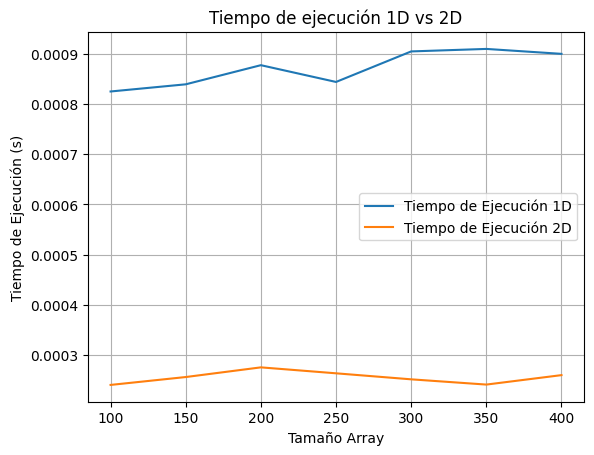

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_1d = pd.read_csv("time_matmult_1D.txt", sep=' ', header=None, names=['Size', 'Time'])
df_2d = pd.read_csv("time_matmult_2D.txt", sep=' ', header=None, names=['Size', 'Time'])

sizes = np.unique(df_1d['Size'])
time_1d = df_1d['Time']
time_2d = df_2d['Time']

mean_time_1d = []
mean_time_2d = []
for i in range(len(sizes)):
  mean_time_1d.append(np.mean(time_1d[i::average]))
  mean_time_2d.append(np.mean(time_2d[i::average]))

plt.plot(sizes, mean_time_1d, label='Tiempo de Ejecución 1D')
plt.plot(sizes, mean_time_2d, label='Tiempo de Ejecución 2D')
plt.legend()
plt.title("Tiempo de ejecución 1D vs 2D")
plt.xlabel("Tamaño Array")
plt.ylabel("Tiempo de Ejecución (s)")
plt.grid()
plt.show()


Al comparar el rendimiento entre la multiplicación de matrices en 1D y en 2D podemos observar que al hacerlo en 2D el porcentaje de tiempo de las actividades en la GPU al realizar la multiplicacion de matrices ocupa menos porcentaje de tiempo que al hacerlo en 1D.

Como reflejamos en la gráfica vemos que al hacer la media de las cinco iteraciones del bucle, el resultado es que las matrices en una dimensión tardan más que al hacerlo en dos dimensiones. Esto puede deberse a que en la memoria los datos están organizados en filas y columnas que es de la forma en la que están compuestas las matrices 2D.

In [ ]:
%%writefile cuda/MatMultF.cu

#include <stdio.h>
#include <math.h>
#include <time.h>
#include <sys/time.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void matrixMultiplicationKernel(float* A, float* B, float* C, int N) {

    int ROW = blockIdx.y*blockDim.y+threadIdx.y;
    int COL = blockIdx.x*blockDim.x+threadIdx.x;

    float tmpSum = 0;

    if (ROW < N && COL < N) {
        // each thread computes one element of the block sub-matrix
        for (int i = 0; i < N; i++) {
            tmpSum += A[ROW * N + i] * B[i * N + COL];
        }
    }
    C[ROW * N + COL] = tmpSum;
}

// programa principal

int main(int argc, char *argv[])
{

    if(argc!=2) {
      printf("Ha olvidado el valor de N, NxN.\n");
      exit(1);
    }
    int N = atoi(argv[1]);
    printf("tamaño= %d x %d \n", N,N);

    struct timeval fin,ini;
    long int tiempoGPU,tiempoCPU;

//    int N = 16;
    float *h_a, *h_b, *h_c;
    float *d_a, *d_b, *d_c;
    int size = N * N * sizeof(float);

    // reserva de memoria en el host
    h_a = (float *)malloc(size);
    h_b = (float *)malloc(size);
    h_c = (float *)malloc(size);

		// Inicializacion de valores en la CPU (host)
    for (int i=0; i<N; i++){
        for (int j=0; j<N; j++){
            h_a[i*N+j] = sin(i);
            h_b[i*N+j] = cos(j);
        }
    }

    // reserva de memoria en la GPU
    cudaMalloc((void **)&d_a, size);
    cudaMalloc((void **)&d_b, size);
    cudaMalloc((void **)&d_c, size);

    // copia de valores a la memoria de la GPU
    cudaMemcpy(d_a, h_a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, size, cudaMemcpyHostToDevice);


    // dimensionar el numero de hilos ajustandolo al tamaño de la matriz
    dim3 threadsPerBlock(N, N);
    dim3 blocksPerGrid(1, 1);
        if (N*N > 1024){
            threadsPerBlock.x = 32;
            threadsPerBlock.y = 32;
            blocksPerGrid.x = ceil(double(N)/double(threadsPerBlock.x));
            blocksPerGrid.y = ceil(double(N)/double(threadsPerBlock.y));
        }
    printf("threadsPerBlock.x= %d  y threadsPerBlock.y= %d \n", threadsPerBlock.x,threadsPerBlock.y);
    printf("blocksPerGrid.x= %d  y blocksPerGrid.y= %d \n", blocksPerGrid.x,blocksPerGrid.y);

    gettimeofday(&ini,NULL);

    // Llamada al Kernel a ejecutar en la GPU
    matrixMultiplicationKernel<<<blocksPerGrid,threadsPerBlock>>>(d_a, d_b, d_c, N);

    gettimeofday(&fin,NULL);
    tiempoGPU=(fin.tv_sec*1000000+fin.tv_usec)-(ini.tv_sec*1000000+ini.tv_usec);
    printf("tiempo GPU: %ld us. \n",tiempoGPU);

   // copia de resultados a la memoria de la CPU
    cudaMemcpy(h_c, d_c, size, cudaMemcpyDeviceToHost);

    cudaDeviceSynchronize();

    float *cpu_C;
    cpu_C = (float *)malloc(size);

     gettimeofday(&ini,NULL);
    // Now do the matrix multiplication on the CPU
    float sum;
    for (int row=0; row<N; row++){
        for (int col=0; col<N; col++){
            sum = 0.f;
            for (int n=0; n<N; n++){
                sum += h_a[row*N+n]*h_b[n*N+col];
            }
            cpu_C[row*N+col] = sum;
        }
    }

    FILE *time = fopen("timef.txt","a");

    FILE *time_cpu = fopen("timef_cpu.txt","a");

    gettimeofday(&fin,NULL);
    tiempoCPU=(fin.tv_sec*1000000+fin.tv_usec)-(ini.tv_sec*1000000+ini.tv_usec);
    printf("tiempo CPU: %ld us. \n",tiempoCPU);

    fprintf(time, "%d %ld\n", N, tiempoGPU);
    fprintf(time_cpu, "%d %ld\n", N, tiempoCPU);


    double err = 0;
    // Check the result and make sure it is correct
    for (int ROW=0; ROW < N; ROW++){
        for (int COL=0; COL < N; COL++){
            err += cpu_C[ROW * N + COL] - h_c[ROW * N + COL];
        }
    }

    printf ("Error = %f ", err);printf("\n");

// liberar memoria

    fclose(time);
    fclose(time_cpu);
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);
    free(h_a);
    free(h_b);
    free(h_c);

    return 0;
}


Writing cuda/MatMultF.cu


In [ ]:
!rm timef.txt
!rm timef_cpu.txt
!nvcc cuda/MatMultF.cu -o cuda/MatMultF
!ls -la cuda

rm: cannot remove 'timef.txt': No such file or directory
rm: cannot remove 'timef_cpu.txt': No such file or directory
total 968
drwxr-xr-x 2 root root   4096 Oct 20 10:40 .
drwxr-xr-x 1 root root   4096 Oct 20 10:40 ..
-rw-r--r-- 1 root root   1852 Oct 20 10:40 MatMult.cu
-rwxr-xr-x 1 root root 971768 Oct 20 10:40 MatMultF
-rw-r--r-- 1 root root   3847 Oct 20 10:40 MatMultF.cu


In [ ]:
!./cuda/MatMultF 32

tamaño= 32 x 32 
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 1  y blocksPerGrid.y= 1 
tiempo GPU: 121713 us. 
tiempo CPU: 182 us. 
Error = 0.000048 


Para interpretar correctamente los resultados, es importante diferenciar la ejecución de la primera vez que se utiliza la GPU al resto veces, y descartar esa primera vez por inicialización de la GPU.

## Comprobar los resultados con diferentes valores de N (tamaño de matriz NxN)

In [ ]:
!rm timef.txt
!rm timef_cpu.txt
!./cuda/MatMultF 16

tamaño= 16 x 16 
threadsPerBlock.x= 16  y threadsPerBlock.y= 16 
blocksPerGrid.x= 1  y blocksPerGrid.y= 1 
tiempo GPU: 218 us. 
tiempo CPU: 229 us. 
Error = -0.000011 


In [ ]:
!nvprof cuda/MatMultF 16

tamaño= 16 x 16 
==505== NVPROF is profiling process 505, command: cuda/MatMultF 16
threadsPerBlock.x= 16  y threadsPerBlock.y= 16 
blocksPerGrid.x= 1  y blocksPerGrid.y= 1 
tiempo GPU: 257 us. 
tiempo CPU: 45 us. 
Error = -0.000011 
==505== Profiling application: cuda/MatMultF 16
==505== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   53.24%  4.7360us         1  4.7360us  4.7360us  4.7360us  matrixMultiplicationKernel(float*, float*, float*, int)
                   24.46%  2.1760us         1  2.1760us  2.1760us  2.1760us  [CUDA memcpy DtoH]
                   22.29%  1.9830us         2     991ns     768ns  1.2150us  [CUDA memcpy HtoD]
      API calls:   99.10%  76.986ms         3  25.662ms  3.4730us  76.976ms  cudaMalloc
                    0.33%  253.59us         1  253.59us  253.59us  253.59us  cudaLaunchKernel
                    0.26%  198.12us       114  1.7370us     183ns  78.642us  cuDeviceGetAttribute
     

In [ ]:
!./cuda/MatMultF 32

tamaño= 32 x 32 
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 1  y blocksPerGrid.y= 1 
tiempo GPU: 184 us. 
tiempo CPU: 132 us. 
Error = 0.000048 


In [ ]:
!nvprof cuda/MatMultF 32

In [ ]:
!./cuda/MatMultF 64

tamaño= 64 x 64 
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 2  y blocksPerGrid.y= 2 
tiempo GPU: 212 us. 
tiempo CPU: 882 us. 
Error = 0.000739 


In [ ]:
!nvprof cuda/MatMultF 64

tamaño= 64 x 64 
==619== NVPROF is profiling process 619, command: cuda/MatMultF 64
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 2  y blocksPerGrid.y= 2 
tiempo GPU: 281 us. 
tiempo CPU: 1627 us. 
Error = 0.000739 
==619== Profiling application: cuda/MatMultF 64
==619== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   65.89%  19.039us         1  19.039us  19.039us  19.039us  matrixMultiplicationKernel(float*, float*, float*, int)
                   22.81%  6.5920us         2  3.2960us  3.2640us  3.3280us  [CUDA memcpy HtoD]
                   11.30%  3.2640us         1  3.2640us  3.2640us  3.2640us  [CUDA memcpy DtoH]
      API calls:   99.53%  167.01ms         3  55.670ms  3.6980us  167.00ms  cudaMalloc
                    0.16%  271.43us         1  271.43us  271.43us  271.43us  cudaLaunchKernel
                    0.13%  213.60us       114  1.8730us     212ns  85.223us  cuDeviceGetAttribute
    

In [ ]:
!./cuda/MatMultF 128

tamaño= 128 x 128 
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 4  y blocksPerGrid.y= 4 
tiempo GPU: 194 us. 
tiempo CPU: 7650 us. 
Error = 0.000598 


In [ ]:
!nvprof cuda/MatMultF 128

tamaño= 128 x 128 
==639== NVPROF is profiling process 639, command: cuda/MatMultF 128
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 4  y blocksPerGrid.y= 4 
tiempo GPU: 253 us. 
tiempo CPU: 14085 us. 
Error = 0.000598 
==639== Profiling application: cuda/MatMultF 128
==639== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   56.61%  34.367us         1  34.367us  34.367us  34.367us  matrixMultiplicationKernel(float*, float*, float*, int)
                   31.89%  19.360us         2  9.6800us  9.3760us  9.9840us  [CUDA memcpy HtoD]
                   11.49%  6.9760us         1  6.9760us  6.9760us  6.9760us  [CUDA memcpy DtoH]
      API calls:   99.30%  129.31ms         3  43.102ms  2.9560us  129.30ms  cudaMalloc
                    0.21%  267.35us       114  2.3450us     197ns  92.543us  cuDeviceGetAttribute
                    0.19%  249.66us         1  249.66us  249.66us  249.66us  cudaLaunchKernel

In [ ]:
!./cuda/MatMultF 1024

tamaño= 1024 x 1024 
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 32  y blocksPerGrid.y= 32 
tiempo GPU: 185 us. 
tiempo CPU: 8169455 us. 
Error = -0.116583 


In [ ]:
!nvprof cuda/MatMultF 1024

tamaño= 1024 x 1024 
==569== NVPROF is profiling process 569, command: cuda/MatMultF 1024
threadsPerBlock.x= 32  y threadsPerBlock.y= 32 
blocksPerGrid.x= 32  y blocksPerGrid.y= 32 
tiempo GPU: 227 us. 
tiempo CPU: 8259720 us. 
Error = -0.116583 
==569== Profiling application: cuda/MatMultF 1024
==569== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   67.82%  6.6587ms         1  6.6587ms  6.6587ms  6.6587ms  matrixMultiplicationKernel(float*, float*, float*, int)
                   16.59%  1.6287ms         1  1.6287ms  1.6287ms  1.6287ms  [CUDA memcpy DtoH]
                   15.59%  1.5304ms         2  765.20us  755.41us  774.99us  [CUDA memcpy HtoD]
      API calls:   83.36%  73.010ms         3  24.337ms  72.685us  72.858ms  cudaMalloc
                   13.18%  11.547ms         3  3.8489ms  938.19us  9.6243ms  cudaMemcpy
                    2.93%  2.5661ms         3  855.37us  232.30us  2.0564ms  cudaFree
        

### Ejercicio T2: Estudie el rendimiento del programa en función de N.

 Para guiarle en este estudio, se plantean a continuación diferentes cuestiones a responder:
- ¿Qué valor de N obtiene Tgpu=Tcpu? ¿Qué pasa antes y después de este N? ¿Por qué?
- ¿Cuál es el máximo valor de N que logra ejecutarse en la GPU? ¿Por qué?
- ¿Qué coste extra en las operaciones de memoria tiene la GPU frente a la CPU? ¿Qué consideraría “justo” añadir para comparar con la CPU?


In [ ]:
!cat timef.txt
!cat timef_cpu.txt

16 218
32 184
64 212
128 194
1024 185
16 229
32 132
64 882
128 7650
1024 8169455


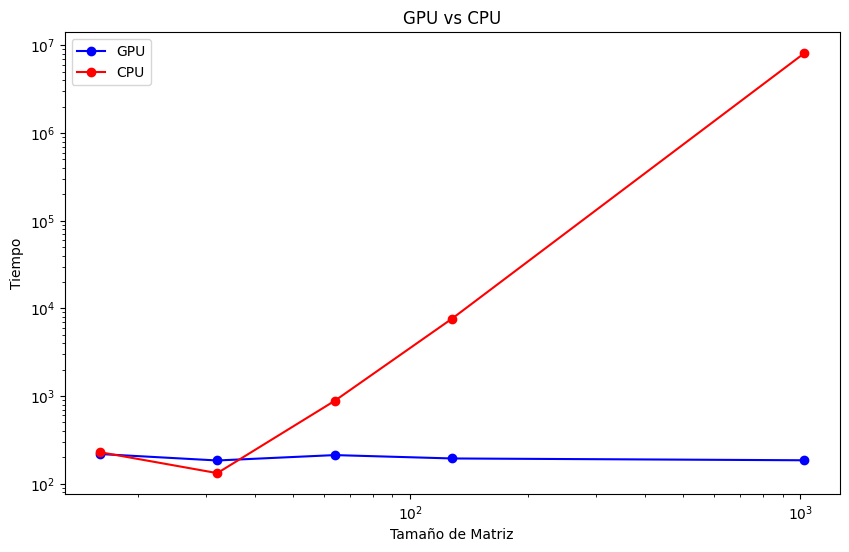

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer los archivos de tiempo para la GPU y la CPU
gpu_data = pd.read_csv("timef.txt", sep=" ", header=None, names=["N", "TiempoGPU"])
cpu_data = pd.read_csv("timef_cpu.txt", sep=" ", header=None, names=["N", "TiempoCPU"])
data = pd.merge(gpu_data, cpu_data, on="N")
plt.figure(figsize=(10, 6))
plt.plot(data["N"], data["TiempoGPU"], label="GPU", marker='o', color='blue')
plt.plot(data["N"], data["TiempoCPU"], label="CPU", marker='o', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Tamaño de Matriz")
plt.ylabel("Tiempo")
plt.title("GPU vs CPU")
plt.legend()
plt.show()

In [ ]:
!nvidia-smi

Sun Oct 20 10:41:33 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

* Para que el tiempo de CPU y el tiempo de GPu coincidan tienen que tener un
tamaño de matriz pequeño, inferior a 10^2. Como podemos observar en la gráfica cuando la mtriz es más pequeño que 10^2 hay un punto en el tamaño que se cruzan y coinciden la CPU y la GPU.

  Cuando la matriz es pequeña el tiempo de GPU es mayor que el de CPU, esto es debido a que se sobrecarga el número de hilos que se lanzan para pdoer calcular matrices pequeñas. Mientras que para tamaños grandes el tiempo de CPU es mayor que el de GPU, ya que la GPU puede lanzar los hilos sin sobrecargarse y poder paralelizar las operaciones para que el rendimiento sea más efectivo.

* Al ejecutar nvidia-smi vemos que tenemos 15GB de memoria disponible de GPU. El programa usa tres matrice las matrices a y b que son las que se van a multiplicar y luego la matiz c que es la matriz resulatante. Todas las matrices son de tamaño n * n. Por lo que para calcular la memoria total utilizada seria multiplicar el tamaño n * n por 3, ya que utilizamos tres matrizes y a su vez multiplicarlo por el tamaño del tipo de dato utilizado. En este caso sería:      3 * n * n* 4 bytes (float). Como n es el tamaño de la matriz, vamos probando con distintos tamaños.

  - (3 * 16 * 16 * 4) / (1024*1024) = 0,00029MB
  - (3 * 32 * 32 * 4) / (1024*1024) = 0,01172MB
  - (3 * 64 * 64 * 4) / (1024*1024) = 0,04688MB
  - (3 * 128 * 128 * 4) / (1024*1024) = 0,1875MB
  - (3 * 1024 * 1024 * 4) / (1024*1024) = 12MB
  - (3 * 2048 * 2048 * 4) / (1024*1024) = 48MB

  Como podemos ver con tamaño N = 2048 se pasa de la memoria disponible de la GPU, por lo que el máximo valor seria para N = 1024.
* La GPU tiene un coste extra en las operaciones frente a CPU, debido a las transferencias de memoria entre el host y la GPU. Antes de hace cualquier operación hacemos esto cudaMemcpyHostToDevice para copiar lo que tenemos en el host en la memoria de la GPU.
Otra de las cosas que hace la GPU a diferencia de la CPU, es el lanzamiento de hilos y su inicilización.